In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/trkiye-home-price-data/home_price.csv


DOSYAYI OKUTALIM

In [2]:
data = pd.read_csv('/kaggle/input/trkiye-home-price-data/home_price.csv')

Kütüphanelere Eklemeler Yapalım

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

Veriyi Tanıyalım 

In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Net_Metrekare,20326.0,1.519645e+02,1.137304e+03,0.0,90.0,120.0,150.0,1.100000e+05
Brüt_Metrekare,20326.0,1.437683e+09,2.049686e+11,2.0,100.0,135.0,170.0,2.922222e+13
Oda_Sayısı,20066.0,3.689400e+00,1.112060e+00,1.0,3.0,4.0,4.0,1.200000e+01
Fiyat,20326.0,4.649510e+06,7.136120e+07,20000.0,1640000.0,2300000.0,3300000.0,7.500000e+09
Binanın_Kat_Sayısı,20326.0,5.185969e+00,3.051288e+00,1.0,3.0,4.0,6.0,1.500000e+01
Banyo_Sayısı,20280.0,1.492751e+00,7.957471e-01,0.0,1.0,1.0,2.0,6.000000e+00


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20326 entries, 0 to 20325
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Net_Metrekare       20326 non-null  int64  
 1   Brüt_Metrekare      20326 non-null  float64
 2   Oda_Sayısı          20066 non-null  float64
 3   Bulunduğu_Kat       18029 non-null  object 
 4   Eşya_Durumu         12928 non-null  object 
 5   Binanın_Yaşı        20326 non-null  object 
 6   Isıtma_Tipi         20326 non-null  object 
 7   Fiyat               20326 non-null  float64
 8   Şehir               20326 non-null  object 
 9   Binanın_Kat_Sayısı  20326 non-null  int64  
 10  Kullanım_Durumu     20326 non-null  object 
 11  Yatırıma_Uygunluk   14750 non-null  object 
 12  Takas               14431 non-null  object 
 13  Tapu_Durumu         9760 non-null   object 
 14  Banyo_Sayısı        20280 non-null  float64
dtypes: float64(4), int64(2), object(9)
memory usage: 2.3+

In [6]:
data.shape

(20326, 15)

In [7]:
data.sample(7).T

,184,5427,7156,8668,11013,7131,7963
Net_Metrekare,75,135,135,90,60,327,110
Brüt_Metrekare,90.0,145.0,200.0,105.0,65.0,328.0,125.0
Oda_Sayısı,2.0,4.0,5.0,3.0,3.0,4.0,3.0
Bulunduğu_Kat,7.Kat,2.Kat,NaN,2.Kat,Yüksek Giriş,NaN,4.Kat
Eşya_Durumu,Boş,Boş,NaN,NaN,NaN,NaN,NaN
Binanın_Yaşı,0 (Yeni),16-20,0 (Yeni),5-10,5-10,21 Ve Üzeri,0 (Yeni)
Isıtma_Tipi,Kombi Doğalgaz,Kombi Doğalgaz,Kombi Doğalgaz,Kombi Doğalgaz,Kombi Doğalgaz,Sobalı,Kombi Doğalgaz
Fiyat,1095000.0,2450000.0,7950000.0,2015000.0,1100000.0,3500000.0,1600000.0
Şehir,adana,burdur,canakkale,denizli,duzce,canakkale,corum
Binanın_Kat_Sayısı,11,4,3,4,4,1,5


In [8]:
data.head(10).T

,0,1,2,3,4,5,6,7,8,9
Net_Metrekare,120,100,89,40,140,40,90,180,105,110
Brüt_Metrekare,150.0,125.0,95.0,55.0,150.0,55.0,110.0,750.0,145.0,130.0
Oda_Sayısı,4.0,4.0,3.0,2.0,4.0,2.0,3.0,5.0,4.0,4.0
Bulunduğu_Kat,4.Kat,3.Kat,4.Kat,6.Kat,Düz Giriş (Zemin),12.Kat,2.Kat,NaN,8.Kat,4.Kat
Eşya_Durumu,Eşyalı,Boş,Boş,Boş,Boş,Boş,NaN,Boş,NaN,NaN
Binanın_Yaşı,21 Ve Üzeri,4,0 (Yeni),0 (Yeni),5-10,5-10,0 (Yeni),16-20,4,5-10
Isıtma_Tipi,Kombi Doğalgaz,Kombi Doğalgaz,Kombi Doğalgaz,Kombi Doğalgaz,Klimalı,Klimalı,Kombi Doğalgaz,Klimalı,Kombi Doğalgaz,Kombi Doğalgaz
Fiyat,950000.0,1250000.0,1750000.0,1300000.0,1700000.0,765000.0,1700000.0,3950000.0,1995000.0,2550000.0
Şehir,adana,adana,adana,adana,adana,adana,adana,adana,adana,adana
Binanın_Kat_Sayısı,6,10,14,14,4,13,14,2,11,11


In [9]:
len(data.isnull())

20326

In [10]:
data.isnull().mean()*100

Net_Metrekare          0.000000
Brüt_Metrekare         0.000000
Oda_Sayısı             1.279150
Bulunduğu_Kat         11.300797
Eşya_Durumu           36.396733
Binanın_Yaşı           0.000000
Isıtma_Tipi            0.000000
Fiyat                  0.000000
Şehir                  0.000000
Binanın_Kat_Sayısı     0.000000
Kullanım_Durumu        0.000000
Yatırıma_Uygunluk     27.432845
Takas                 29.002263
Tapu_Durumu           51.982682
Banyo_Sayısı           0.226311
dtype: float64

In [11]:
data.sort_values(by="Net_Metrekare", ascending=False).head(10)

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Net_Metrekare,Brüt_Metrekare,Oda_Sayısı,Bulunduğu_Kat,Eşya_Durumu,Binanın_Yaşı,Isıtma_Tipi,Fiyat,Şehir,Binanın_Kat_Sayısı,Kullanım_Durumu,Yatırıma_Uygunluk,Takas,Tapu_Durumu,Banyo_Sayısı
11513,110000,120000.0,4.0,3.Kat,NaN,2,Kombi Doğalgaz,2250000.0,edirne,4,Mülk Sahibi Oturuyor,Uygun,Yok,Kat Mülkiyeti,2.0
14103,110000,120000.0,3.0,10.Kat,NaN,3,Merkezi Doğalgaz,2350000.0,gaziantep,10,Boş,NaN,NaN,NaN,1.0
3458,16500,17000.0,NaN,NaN,Eşyalı,5-10,Kat Kaloriferi,235000000.0,antalya,3,Boş,Uygun,Yok,Müstakil Tapulu,6.0
18827,16000,1650000.0,3.0,NaN,NaN,4,Isıtma Yok,16000000.0,kirklareli,2,Boş,Uygun,NaN,NaN,6.0
17009,15450,15460.0,4.0,1.Kat,NaN,16-20,Sobalı,2250000.0,kars,1,Mülk Sahibi Oturuyor,NaN,NaN,NaN,1.0
10963,15000,150000.0,5.0,5.Kat,NaN,16-20,Klimalı,900000.0,diyarbakir,7,Boş,NaN,NaN,NaN,1.0
18864,14950,15000.0,7.0,NaN,NaN,3,Isıtma Yok,16000000.0,kirklareli,1,Boş,Uygun,Yok,Kat Mülkiyeti,2.0
2032,12500,25000.0,5.5,NaN,Eşyalı,11-15,Merkezi Doğalgaz,13250000.0,afyonkarahisar,1,Mülk Sahibi Oturuyor,Uygun,Var,Kat Mülkiyeti,2.0
12212,11500,13500.0,5.0,Düz Giriş (Zemin),Eşyalı,21 Ve Üzeri,Sobalı,4500000.0,erzincan,1,Mülk Sahibi Oturuyor,Uygun,Yok,Arsa Tapulu,1.0
2045,11308,11310.0,NaN,NaN,NaN,0 (Yeni),Isıtma Yok,1250000.0,afyonkarahisar,1,Boş,NaN,Var,Arsa Tapulu,6.0


In [12]:
data["Şehir"].value_counts().sort_values(ascending=False)

Şehir
antalya           1450
adana             1449
denizli           1449
diyarbakir        1449
gaziantep         1446
kocaeli           1325
canakkale          954
eskisehir          947
bursa              847
kirklareli         659
corum              640
balikesir          545
afyonkarahisar     507
edirne             497
giresun            484
kayseri            478
hatay              446
izmir              385
duzce              366
elazig             358
kilis              332
batman             326
bolu               325
kahramanmaras      287
isparta            250
kars               215
burdur             214
amasya             208
kirikkale          167
bartin             146
kastamonu          143
erzurum            125
karabuk            121
adiyaman           116
konya              107
aksaray            106
karaman            104
bilecik             93
aydin               59
bayburt             46
gumushane           31
erzincan            29
kirsehir            25
canki

In [13]:
data["Şehir"].value_counts().max() 

1450

In [14]:
data["Şehir"].value_counts().min()

1

In [15]:
data['Kullanım_Durumu'].value_counts()

Kullanım_Durumu
Boş                     12594
Mülk Sahibi Oturuyor     4160
Kiracı Oturuyor          3572
Name: count, dtype: int64

In [16]:
data['Isıtma_Tipi'].value_counts()

Isıtma_Tipi
Kombi Doğalgaz         12003
Yerden Isıtma           1807
Klimalı                 1749
Merkezi Doğalgaz        1599
Sobalı                   853
Merkezi (Pay Ölçer)      807
Isıtma Yok               462
Kat Kaloriferi           314
Doğalgaz Sobalı          221
Diğer                    175
Merkezi Kömür            126
Jeotermal                109
Güneş Enerjisi           101
Name: count, dtype: int64

In [17]:
data['Bulunduğu_Kat'].value_counts()

Bulunduğu_Kat
2.Kat                3760
3.Kat                3012
1.Kat                2816
4.Kat                1920
Yüksek Giriş         1215
5.Kat                1173
Düz Giriş (Zemin)     616
6.Kat                 573
7.Kat                 518
Bahçe Katı            411
8.Kat                 257
9.Kat                 236
Çatı Dubleks          214
10.Kat                172
Müstakil              154
Çatı Katı             131
11.Kat                131
Villa Tipi            126
12.Kat                104
Bahçe Dublex           98
13.Kat                 72
14.Kat                 60
Kot 1 (-1).Kat         59
Bodrum Kat             52
Kot 3 (-3).Kat         49
Kot 2 (-2).Kat         48
Kot 4 (-4).Kat         16
15.Kat                 12
18.Kat                  6
17.Kat                  5
16.Kat                  5
21.Kat                  3
26.Kat                  1
40+.Kat                 1
19.Kat                  1
30.Kat                  1
22.Kat                  1
Name: count, dtype: int6

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


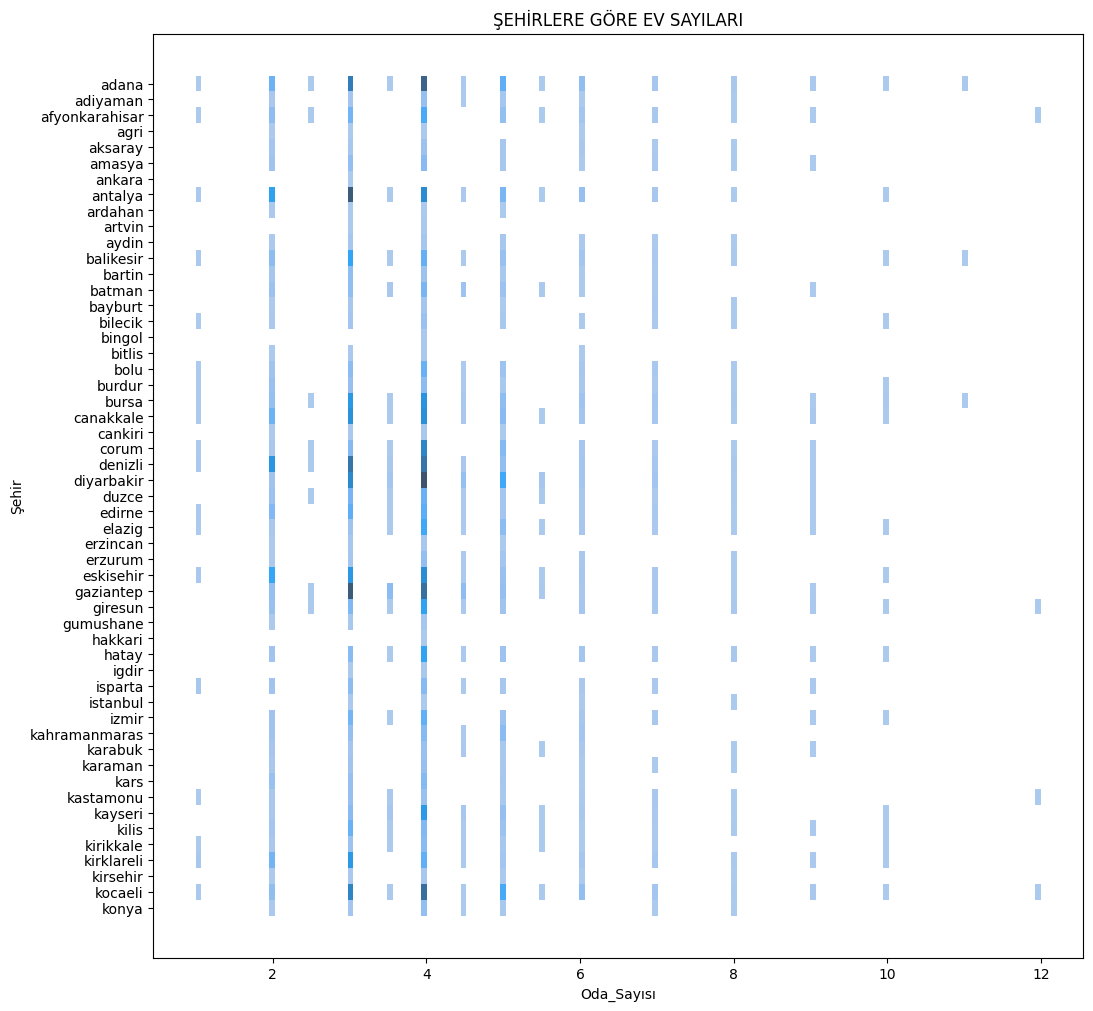

In [18]:
plt.figure(figsize=(12,12))
sns.histplot(data, x='Oda_Sayısı', y='Şehir')
plt.title('ŞEHİRLERE GÖRE EV SAYILARI');

In [19]:
np.max(data["Fiyat"])

7500000000.0

In [20]:
data['Fiyat'].mean()

4649510.21760307

In [21]:
np.max(data["Fiyat"])

7500000000.0

In [22]:
np.min(data["Fiyat"])

20000.0

In [23]:
x = data['Brüt_Metrekare']>115  
print(len(data[x]))

13006


In [24]:
x = data['Brüt_Metrekare']>100  
len(data[x])

14953

In [25]:
len(data[np.logical_and(data['Oda_Sayısı']>3 , data['Net_Metrekare']>120 )])

/usr/local/lib/python3.10/dist-packages/pandas/core/computation/expressions.py:73: RuntimeWarning: invalid value encountered in greater
  return op(a, b)


8703

In [26]:
a=data['Binanın_Yaşı']==16-20, data['Isıtma_Tipi']== 'Klimalı', ['Şehir']== 'MERSİN'
print(a)
len(a)

(0        False
1        False
2        False
3        False
4        False
         ...  
20321    False
20322    False
20323    False
20324    False
20325    False
Name: Binanın_Yaşı, Length: 20326, dtype: bool, 0        False
1        False
2        False
3        False
4         True
         ...  
20321    False
20322    False
20323    False
20324    False
20325    False
Name: Isıtma_Tipi, Length: 20326, dtype: bool, False)


3

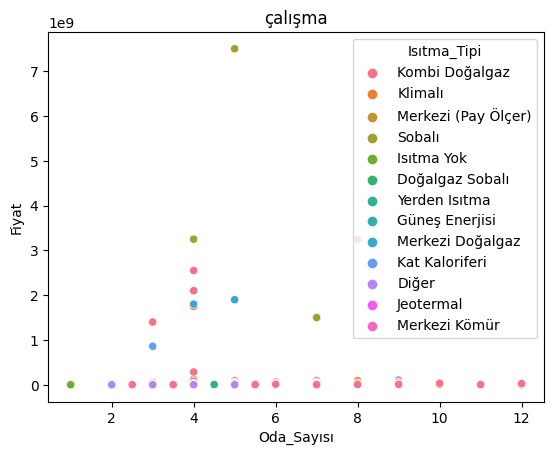

In [27]:
sns.scatterplot(data, x="Oda_Sayısı", y="Fiyat", hue="Isıtma_Tipi")
plt.title("çalışma")
plt.show()

In [28]:
data.groupby(['Fiyat']).mean(numeric_only=True)['Oda_Sayısı']

/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.10/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


Fiyat
2.000000e+04    3.5
2.500000e+04    2.5
2.900000e+04    NaN
3.000000e+04    3.0
3.500000e+04    2.5
               ... 
1.899000e+09    5.0
2.100000e+09    4.0
2.550000e+09    4.0
3.250000e+09    6.0
7.500000e+09    5.0
Name: Oda_Sayısı, Length: 1558, dtype: float64

In [29]:
colors = ['lightcoral', 'skyblue', 'yellowgreen']
plt.pie(data='Kullanım_Durumu)
plt.title("Kullanım Durumu")
plt.axis('equal')  # Daireyi düzgün yapar
plt.show

SyntaxError: unterminated string literal (detected at line 2) (<ipython-input-29-3201444a0b2e>, line 2)